# benchmark_02. Reconstructing the Legacy LROM Method Walkthrough

This benchmark validates the version-1 `lrom` package by recreating, through
its public API, every study and figure of the archived legacy notebook
`scientific_archive/legacy_code/Legacy_benchmark/notebooks/02_lrom_method_walkthrough.ipynb`
(benchmarks are named after the legacy notebook they recreate).

Two independent implementations are compared on identical physics:

- the `lrom` package (one object: `.sampling`, `.train`, `.predict`) builds a
  central-reference reduced basis and learns the reduced operators (LROM);
- a notebook-owned ROSE emulator runs the public `rose` package natively with
  its free-reference basis convention.

Because the two use different basis conventions, reduced-basis coefficients
are only ever compared within one convention (each method against its own
least-squares projection). Wavefunctions and their errors are compared
directly on the shared physical radial mesh, in fm.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import numpy as np
from numba import njit

ROOT = next(
    candidate
    for candidate in (Path.cwd(), *Path.cwd().parents)
    if (candidate / "lrom").is_dir()
)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import scipy.special
if not hasattr(scipy.special, "sph_harm") and hasattr(scipy.special, "sph_harm_y"):
    # legacy sph_harm took (theta=azimuthal, phi=polar); sph_harm_y takes (polar, azimuthal)
    scipy.special.sph_harm = lambda m, n, theta, phi: scipy.special.sph_harm_y(n, m, phi, theta)

import rose
import lrom

plt.rcParams.update(
    {"figure.dpi": 120, "axes.grid": True, "grid.alpha": 0.25}
)

## Shared physical setup

All studies use neutron scattering from calcium-40 at 14.1 MeV, a four-vector
wavefunction basis, an eight-vector interaction basis, and separate training
and testing rows. The one-parameter studies isolate `Vv` and `Rv`; the later
studies vary both parameters together.

In [2]:
# Shared physics: 40Ca(n,n) at 14.1 MeV, exact l=0 partial wave.
# All studies below reuse these knobs so figures differ only by design choices.
TARGET = (40, 20)
PROJECTILE = (1, 0)
LAB_ENERGY = 14.1
BASIS_SIZE = 4
EIM_BASIS_SIZE = 8
MESH_SIZE = 800
DIFFERENCE_FLOOR = 1e-5

# Global scan windows and axis policy shared by every study below, so all
# figures cover identical physical ranges and identical log-error axes.
VV_SCAN_LIMITS = (30.0, 70.0)   # Woods-Saxon depth Vv [MeV]
RV_SCAN_LIMITS = (3.0, 5.0)     # Woods-Saxon radius Rv [fm]
ERROR_YMAX = 1e0                # shared top for all log error axes (data max ~0.7)

central_probe = lrom.LROM(
    target=TARGET,
    projectile=PROJECTILE,
    lab_energy=LAB_ENERGY,
    l=0,
    potential="ws_3",
)
CENTRAL = dict(central_probe.central_parameters)
V0, R0, A0 = (CENTRAL[name] for name in ("Vv", "Rv", "av"))
print("lrom central parameters:", {name: CENTRAL[name] for name in ("Vv", "Rv", "av")})

lrom central parameters: {'Vv': 48.822175142383706, 'Rv': 4.053875273743491, 'av': 0.671852}


In [3]:
@njit
def rose_real_woods_saxon(r, alpha):
    vv, rv, av = alpha
    return -vv / (1.0 + np.exp((r - rv) / av))

## Varying only the real volume depth

In [4]:
# Study 1: vary only the Woods-Saxon depth Vv (an affine parameter).
# The lrom object samples the FOM, builds the centered basis, and fits the
# learned reduced operators; the ROSE emulator below is trained independently
# on the same parameter rows with its native free-reference workflow.
vv_train = np.linspace(0.90 * V0, 1.10 * V0, 35)
vv_test = np.linspace(*VV_SCAN_LIMITS, 41)
vv_emulator = lrom.LROM(
    target=TARGET, projectile=PROJECTILE, lab_energy=LAB_ENERGY,
    l=0, potential="ws_1",
)
vv_emulator.sampling(
    training_grid={"Vv": vv_train},
    testing_grid={"Vv": vv_test},
    mesh_size=MESH_SIZE,
    eim_basis_size=EIM_BASIS_SIZE,
)
vv_emulator.train(basis_size=BASIS_SIZE, predictor="parameters", predictor_count=1)
vv_rose_rows = vv_emulator.samples.design.training.values
vv_rose_test_rows = vv_emulator.samples.design.testing.values
vv_rose_rho = vv_emulator.samples.mesh.rho
vv_rose_bounds = np.column_stack([
    np.minimum(vv_rose_rows.min(axis=0), vv_rose_test_rows.min(axis=0)),
    np.maximum(vv_rose_rows.max(axis=0), vv_rose_test_rows.max(axis=0)),
])
vv_rose_interactions = rose.InteractionEIMSpace(
    l_max=0,
    coordinate_space_potential=rose_real_woods_saxon,
    n_theta=3,
    mu=vv_emulator.kinematics.mu,
    energy=vv_emulator.kinematics.e_com,
    is_complex=False,
    training_info=vv_rose_bounds,
    n_basis=EIM_BASIS_SIZE,
    rho_mesh=vv_rose_rho,
)
vv_rose_solver = rose.SchroedingerEquation.make_base_solver(
    s_0=6 * np.pi, rk_tols=[1e-9, 1e-9], domain=np.array([vv_rose_rho[0], vv_rose_rho[-1]])
)
vv_rose_emulator = rose.ScatteringAmplitudeEmulator.from_train(
    vv_rose_interactions,
    vv_rose_rows,
    base_solver=vv_rose_solver,
    l_max=0,
    angles=np.linspace(1, 179, 120) * np.pi / 180,
    n_basis=BASIS_SIZE,
    use_svd=True,
    scale=False,
    s_mesh=vv_rose_rho,
    Smatrix_abs_tol=1e-8,
)
vv_rose_rbe = vv_rose_emulator.rbes[0][0]
vv_rose_coeff_train = np.asarray([vv_rose_rbe.coefficients(row) for row in vv_rose_rows])
vv_rose_coeff_test = np.asarray([vv_rose_rbe.coefficients(row) for row in vv_rose_test_rows])
vv_rose_wf_train = np.asarray([vv_rose_rbe.emulate_wave_function(row) for row in vv_rose_rows])
vv_rose_wf_test = np.asarray([vv_rose_rbe.emulate_wave_function(row) for row in vv_rose_test_rows])
vv_rose_weights = np.empty_like(vv_rose_rho)
vv_rose_weights[1:-1] = 0.5 * (vv_rose_rho[2:] - vv_rose_rho[:-2])
vv_rose_weights[0] = 0.5 * (vv_rose_rho[1] - vv_rose_rho[0])
vv_rose_weights[-1] = 0.5 * (vv_rose_rho[-1] - vv_rose_rho[-2])
vv_rose_sqrt_w = np.sqrt(vv_rose_weights)
vv_rose_vectors_w = vv_rose_sqrt_w[:, None] * vv_rose_rbe.basis.vectors
vv_rose_ls_train = np.asarray([
    np.linalg.lstsq(vv_rose_vectors_w, vv_rose_sqrt_w * (phi - vv_rose_rbe.basis.phi_0), rcond=None)[0]
    for phi in vv_emulator.samples.training_wavefunctions[0]
])
vv_rose_ls_test = np.asarray([
    np.linalg.lstsq(vv_rose_vectors_w, vv_rose_sqrt_w * (phi - vv_rose_rbe.basis.phi_0), rcond=None)[0]
    for phi in vv_emulator.samples.testing_wavefunctions[0]
])
vv_rose_error_train = np.linalg.norm(vv_rose_wf_train - vv_emulator.samples.training_wavefunctions[0], axis=1) / np.maximum(np.linalg.norm(vv_emulator.samples.training_wavefunctions[0], axis=1), 1e-300)
vv_rose_error_test = np.linalg.norm(vv_rose_wf_test - vv_emulator.samples.testing_wavefunctions[0], axis=1) / np.maximum(np.linalg.norm(vv_emulator.samples.testing_wavefunctions[0], axis=1), 1e-300)


  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:01<00:00,  1.72s/it]

100%|██████████| 1/1 [00:01<00:00,  1.72s/it]

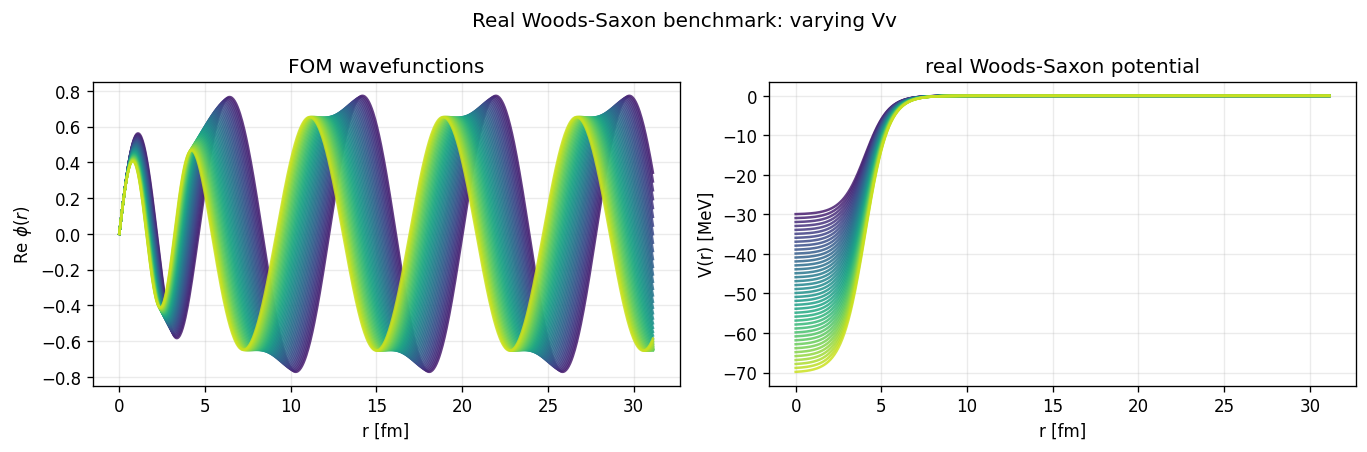

In [5]:
# FIGURE: vv-rainbow
radius = vv_emulator.samples.mesh.radius
colors = plt.cm.viridis(np.linspace(0.08, 0.92, len(vv_emulator.samples.design.testing.values)))
fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.8))
for color, phi, potential in zip(colors, vv_emulator.samples.testing_wavefunctions[0], vv_emulator.samples.testing_potentials):
    axes[0].plot(radius, phi.real, color=color, lw=1.5, alpha=0.85)
    axes[1].plot(radius, potential.real, color=color, lw=1.5, alpha=0.85)
axes[0].set(xlabel="r [fm]", ylabel=r"Re $\phi(r)$", title="FOM wavefunctions")
axes[1].set(xlabel="r [fm]", ylabel="V(r) [MeV]", title="real Woods-Saxon potential")
fig.suptitle("Real Woods-Saxon benchmark: varying Vv")
fig.tight_layout()
plt.show()

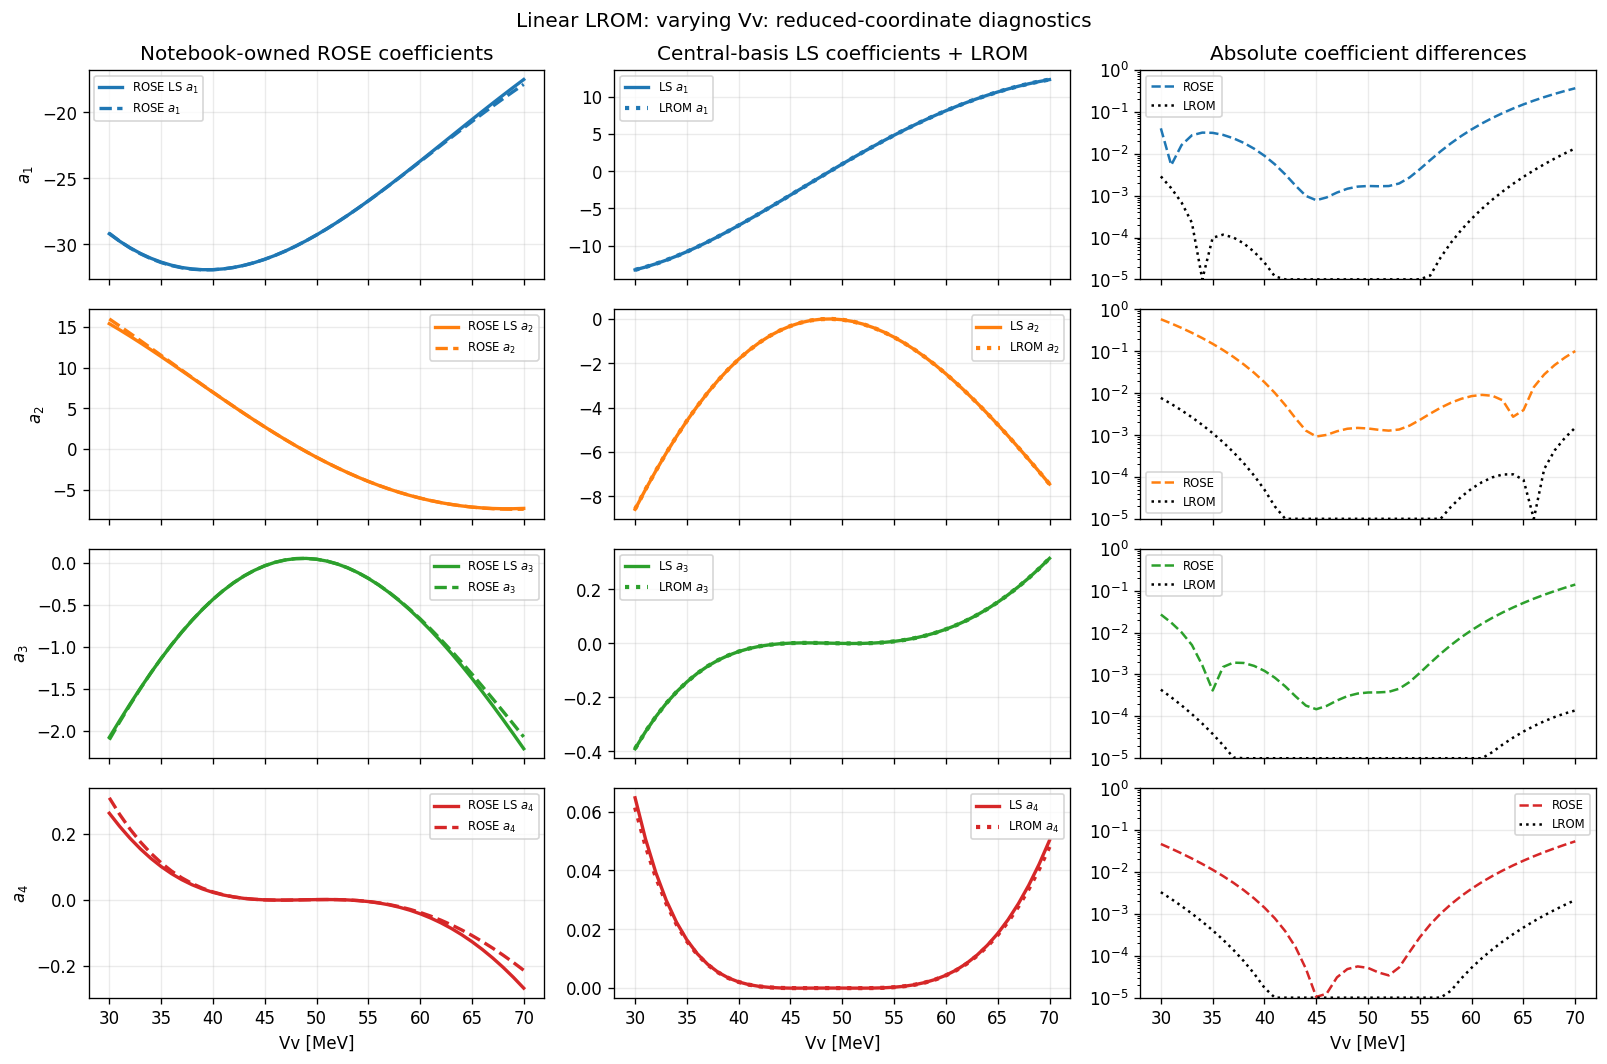

In [6]:
# FIGURE: vv-coefficients
results = vv_emulator.testing_results
ls = results.coefficients["ls"][0]
rose_ls = vv_rose_ls_test
rose_coeff = vv_rose_coeff_test
lrom_coeff = results.coefficients["lrom"][0]
n_show = min(BASIS_SIZE, ls.shape[1])
colors = plt.cm.tab10(np.arange(n_show))
fig, axes = plt.subplots(n_show, 3, figsize=(13.5, 2.25 * n_show), sharex="col")
for i in range(n_show):
    axes[i, 0].plot(vv_test, rose_ls[:, i].real, color=colors[i], lw=2, label=fr"ROSE LS $a_{i+1}$")
    axes[i, 0].plot(vv_test, rose_coeff[:, i].real, "--", color=colors[i], lw=2, label=fr"ROSE $a_{i+1}$")
    axes[i, 1].plot(vv_test, ls[:, i].real, color=colors[i], lw=2, label=fr"LS $a_{i+1}$")
    axes[i, 1].plot(vv_test, lrom_coeff[:, i].real, ":", color=colors[i], lw=2.5, label=fr"LROM $a_{i+1}$")
    axes[i, 2].semilogy(vv_test, np.maximum(np.abs(rose_coeff[:, i] - rose_ls[:, i]), DIFFERENCE_FLOOR), "--", color=colors[i], label="ROSE")
    axes[i, 2].semilogy(vv_test, np.maximum(np.abs(lrom_coeff[:, i] - ls[:, i]), DIFFERENCE_FLOOR), ":", color="black", label="LROM")
    axes[i, 0].set_ylabel(fr"$a_{i+1}$")
axes[0, 0].set_title("Notebook-owned ROSE coefficients")
axes[0, 1].set_title("Central-basis LS coefficients + LROM")
axes[0, 2].set_title("Absolute coefficient differences")
for ax in axes[-1]: ax.set_xlabel("Vv [MeV]")
for ax in axes.ravel(): ax.legend(fontsize=7)
fig.suptitle("Linear LROM: varying Vv: reduced-coordinate diagnostics")
for difference_ax in axes[:, 2]:
    difference_ax.set_ylim(bottom=DIFFERENCE_FLOOR, top=ERROR_YMAX)
fig.tight_layout()
plt.show()

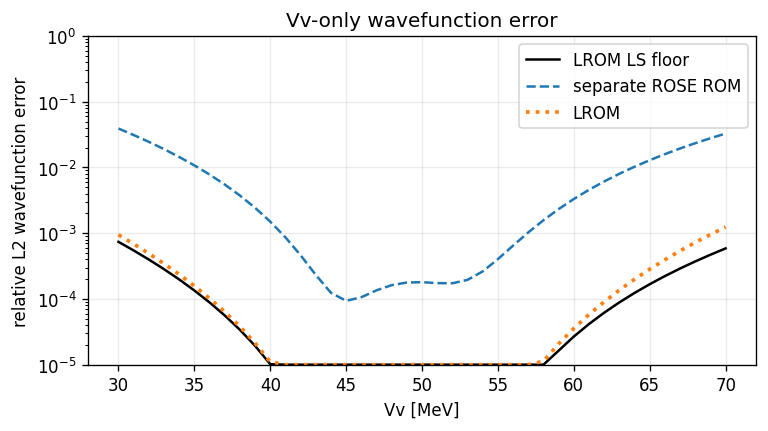

In [7]:
# FIGURE: vv-wavefunction-errors
metrics = vv_emulator.testing_results.metrics["relative_l2"][0]
fig, ax = plt.subplots(figsize=(6.5, 3.7))
ax.semilogy(vv_test, np.maximum(metrics["ls"], DIFFERENCE_FLOOR), color="black", label="LROM LS floor")
ax.semilogy(vv_test, np.maximum(vv_rose_error_test, DIFFERENCE_FLOOR), "--", label="separate ROSE ROM")
ax.semilogy(vv_test, np.maximum(metrics["lrom"], DIFFERENCE_FLOOR), ":", lw=2.2, label="LROM")
ax.set(xlabel="Vv [MeV]", ylabel="relative L2 wavefunction error", title="Vv-only wavefunction error")
ax.legend()
ax.set_ylim(bottom=DIFFERENCE_FLOOR, top=ERROR_YMAX)
fig.tight_layout()
plt.show()

## Varying only the radius

In [8]:
# Study 2: vary only the radius Rv. The potential now changes shape
# nonlinearly, so a single linear parameter predictor has to work harder.
rv_train = np.linspace(0.94 * R0, 1.06 * R0, 35)
rv_test = np.linspace(*RV_SCAN_LIMITS, 41)
rv_emulator = lrom.LROM(
    target=TARGET, projectile=PROJECTILE, lab_energy=LAB_ENERGY,
    l=0, potential="ws_3",
)
rv_emulator.sampling(
    training_grid={"Rv": rv_train},
    testing_grid={"Rv": rv_test},
    mesh_size=MESH_SIZE,
    eim_basis_size=EIM_BASIS_SIZE,
)
rv_emulator.train(basis_size=BASIS_SIZE, predictor="parameters", predictor_count=1)
rv_rose_rows = rv_emulator.samples.design.training.values
rv_rose_test_rows = rv_emulator.samples.design.testing.values
rv_rose_rho = rv_emulator.samples.mesh.rho
rv_rose_bounds = np.column_stack([
    np.minimum(rv_rose_rows.min(axis=0), rv_rose_test_rows.min(axis=0)),
    np.maximum(rv_rose_rows.max(axis=0), rv_rose_test_rows.max(axis=0)),
])
rv_rose_interactions = rose.InteractionEIMSpace(
    l_max=0,
    coordinate_space_potential=rose_real_woods_saxon,
    n_theta=3,
    mu=rv_emulator.kinematics.mu,
    energy=rv_emulator.kinematics.e_com,
    is_complex=False,
    training_info=rv_rose_bounds,
    n_basis=EIM_BASIS_SIZE,
    rho_mesh=rv_rose_rho,
)
rv_rose_solver = rose.SchroedingerEquation.make_base_solver(
    s_0=6 * np.pi, rk_tols=[1e-9, 1e-9], domain=np.array([rv_rose_rho[0], rv_rose_rho[-1]])
)
rv_rose_emulator = rose.ScatteringAmplitudeEmulator.from_train(
    rv_rose_interactions,
    rv_rose_rows,
    base_solver=rv_rose_solver,
    l_max=0,
    angles=np.linspace(1, 179, 120) * np.pi / 180,
    n_basis=BASIS_SIZE,
    use_svd=True,
    scale=False,
    s_mesh=rv_rose_rho,
    Smatrix_abs_tol=1e-8,
)
rv_rose_rbe = rv_rose_emulator.rbes[0][0]
rv_rose_coeff_train = np.asarray([rv_rose_rbe.coefficients(row) for row in rv_rose_rows])
rv_rose_coeff_test = np.asarray([rv_rose_rbe.coefficients(row) for row in rv_rose_test_rows])
rv_rose_wf_train = np.asarray([rv_rose_rbe.emulate_wave_function(row) for row in rv_rose_rows])
rv_rose_wf_test = np.asarray([rv_rose_rbe.emulate_wave_function(row) for row in rv_rose_test_rows])
rv_rose_weights = np.empty_like(rv_rose_rho)
rv_rose_weights[1:-1] = 0.5 * (rv_rose_rho[2:] - rv_rose_rho[:-2])
rv_rose_weights[0] = 0.5 * (rv_rose_rho[1] - rv_rose_rho[0])
rv_rose_weights[-1] = 0.5 * (rv_rose_rho[-1] - rv_rose_rho[-2])
rv_rose_sqrt_w = np.sqrt(rv_rose_weights)
rv_rose_vectors_w = rv_rose_sqrt_w[:, None] * rv_rose_rbe.basis.vectors
rv_rose_ls_train = np.asarray([
    np.linalg.lstsq(rv_rose_vectors_w, rv_rose_sqrt_w * (phi - rv_rose_rbe.basis.phi_0), rcond=None)[0]
    for phi in rv_emulator.samples.training_wavefunctions[0]
])
rv_rose_ls_test = np.asarray([
    np.linalg.lstsq(rv_rose_vectors_w, rv_rose_sqrt_w * (phi - rv_rose_rbe.basis.phi_0), rcond=None)[0]
    for phi in rv_emulator.samples.testing_wavefunctions[0]
])
rv_rose_error_train = np.linalg.norm(rv_rose_wf_train - rv_emulator.samples.training_wavefunctions[0], axis=1) / np.maximum(np.linalg.norm(rv_emulator.samples.training_wavefunctions[0], axis=1), 1e-300)
rv_rose_error_test = np.linalg.norm(rv_rose_wf_test - rv_emulator.samples.testing_wavefunctions[0], axis=1) / np.maximum(np.linalg.norm(rv_emulator.samples.testing_wavefunctions[0], axis=1), 1e-300)


  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:01<00:00,  1.61s/it]

100%|██████████| 1/1 [00:01<00:00,  1.62s/it]

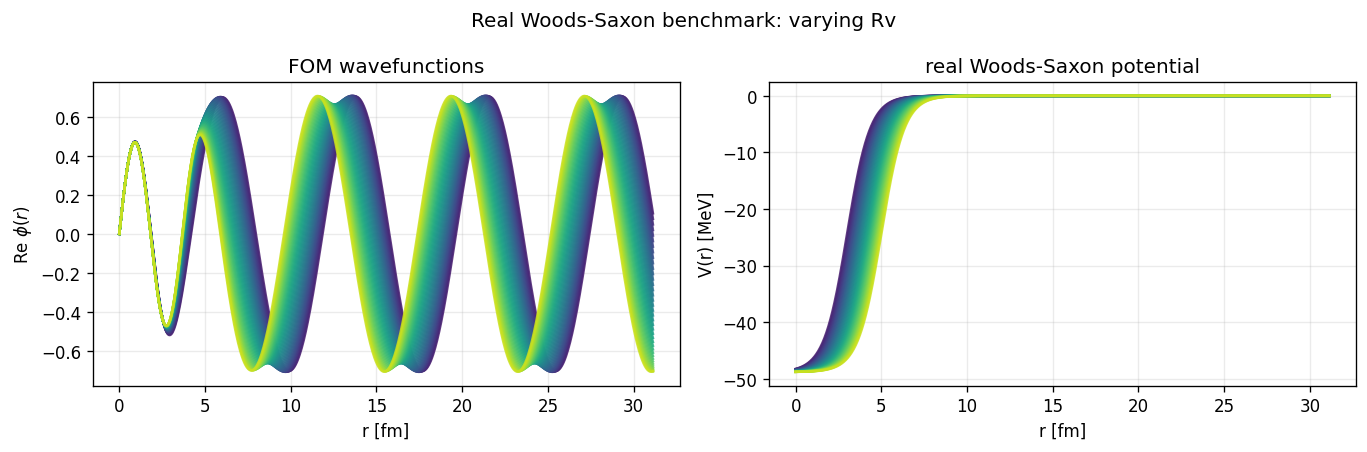

In [9]:
# FIGURE: rv-rainbow
radius = rv_emulator.samples.mesh.radius
colors = plt.cm.viridis(np.linspace(0.08, 0.92, len(rv_emulator.samples.design.testing.values)))
fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.8))
for color, phi, potential in zip(colors, rv_emulator.samples.testing_wavefunctions[0], rv_emulator.samples.testing_potentials):
    axes[0].plot(radius, phi.real, color=color, lw=1.5, alpha=0.85)
    axes[1].plot(radius, potential.real, color=color, lw=1.5, alpha=0.85)
axes[0].set(xlabel="r [fm]", ylabel=r"Re $\phi(r)$", title="FOM wavefunctions")
axes[1].set(xlabel="r [fm]", ylabel="V(r) [MeV]", title="real Woods-Saxon potential")
fig.suptitle("Real Woods-Saxon benchmark: varying Rv")
fig.tight_layout()
plt.show()

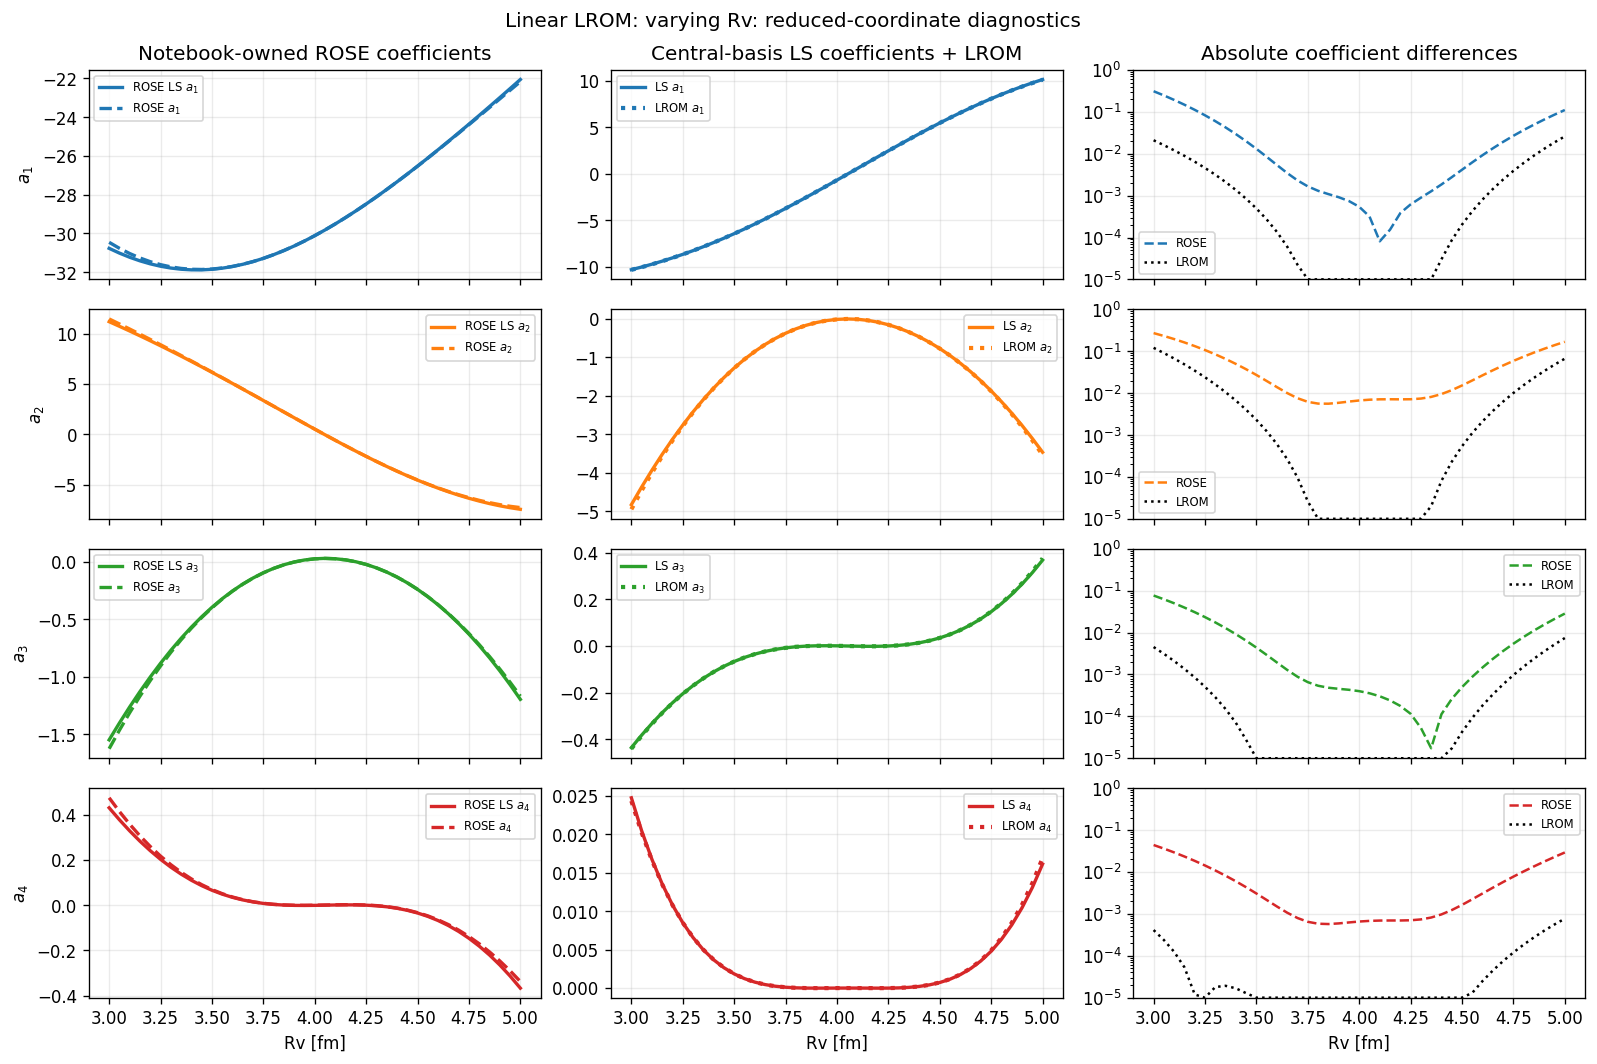

In [10]:
# FIGURE: rv-coefficients
results = rv_emulator.testing_results
ls = results.coefficients["ls"][0]
rose_ls = rv_rose_ls_test
rose_coeff = rv_rose_coeff_test
lrom_coeff = results.coefficients["lrom"][0]
n_show = min(BASIS_SIZE, ls.shape[1])
colors = plt.cm.tab10(np.arange(n_show))
fig, axes = plt.subplots(n_show, 3, figsize=(13.5, 2.25 * n_show), sharex="col")
for i in range(n_show):
    axes[i, 0].plot(rv_test, rose_ls[:, i].real, color=colors[i], lw=2, label=fr"ROSE LS $a_{i+1}$")
    axes[i, 0].plot(rv_test, rose_coeff[:, i].real, "--", color=colors[i], lw=2, label=fr"ROSE $a_{i+1}$")
    axes[i, 1].plot(rv_test, ls[:, i].real, color=colors[i], lw=2, label=fr"LS $a_{i+1}$")
    axes[i, 1].plot(rv_test, lrom_coeff[:, i].real, ":", color=colors[i], lw=2.5, label=fr"LROM $a_{i+1}$")
    axes[i, 2].semilogy(rv_test, np.maximum(np.abs(rose_coeff[:, i] - rose_ls[:, i]), DIFFERENCE_FLOOR), "--", color=colors[i], label="ROSE")
    axes[i, 2].semilogy(rv_test, np.maximum(np.abs(lrom_coeff[:, i] - ls[:, i]), DIFFERENCE_FLOOR), ":", color="black", label="LROM")
    axes[i, 0].set_ylabel(fr"$a_{i+1}$")
axes[0, 0].set_title("Notebook-owned ROSE coefficients")
axes[0, 1].set_title("Central-basis LS coefficients + LROM")
axes[0, 2].set_title("Absolute coefficient differences")
for ax in axes[-1]: ax.set_xlabel("Rv [fm]")
for ax in axes.ravel(): ax.legend(fontsize=7)
fig.suptitle("Linear LROM: varying Rv: reduced-coordinate diagnostics")
for difference_ax in axes[:, 2]:
    difference_ax.set_ylim(bottom=DIFFERENCE_FLOOR, top=ERROR_YMAX)
fig.tight_layout()
plt.show()

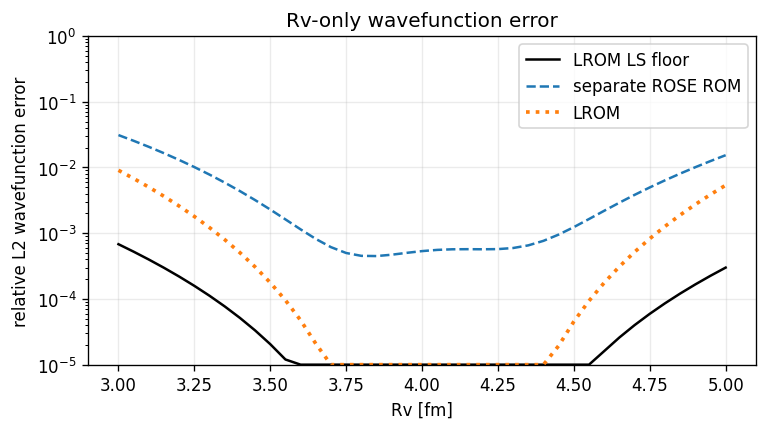

In [11]:
# FIGURE: rv-wavefunction-errors
metrics = rv_emulator.testing_results.metrics["relative_l2"][0]
fig, ax = plt.subplots(figsize=(6.5, 3.7))
ax.semilogy(rv_test, np.maximum(metrics["ls"], DIFFERENCE_FLOOR), color="black", label="LROM LS floor")
ax.semilogy(rv_test, np.maximum(rv_rose_error_test, DIFFERENCE_FLOOR), "--", label="separate ROSE ROM")
ax.semilogy(rv_test, np.maximum(metrics["lrom"], DIFFERENCE_FLOOR), ":", lw=2.2, label="LROM")
ax.set(xlabel="Rv [fm]", ylabel="relative L2 wavefunction error", title="Rv-only wavefunction error")
ax.legend()
ax.set_ylim(bottom=DIFFERENCE_FLOOR, top=ERROR_YMAX)
fig.tight_layout()
plt.show()

## Broad Vv/Rv box

The broad training box stresses raw centered-parameter predictors. Testing is
organized as two row-aligned one-at-a-time scans, first in `Vv` and then in
`Rv`, so every coefficient and error trajectory has an unambiguous x-axis.

In [12]:
# Study 3: a broad random Vv/Rv box plus one-at-a-time scans through the
# center, used to expose where raw linear parameter predictors break down.
rng = np.random.default_rng(1204)
n_train = 70
n_scan = 43
broad_train_vv = V0 + rng.uniform(-1, 1, n_train) * (0.22 * V0)
broad_train_rv = R0 + rng.uniform(-1, 1, n_train) * (0.20 * R0)
vv_scan = np.linspace(*VV_SCAN_LIMITS, n_scan)
rv_scan = np.linspace(*RV_SCAN_LIMITS, n_scan)
broad_test_vv = np.concatenate([vv_scan, np.full(n_scan, V0)])
broad_test_rv = np.concatenate([np.full(n_scan, R0), rv_scan])
scan_slices = {"Vv": slice(0, n_scan), "Rv": slice(n_scan, 2 * n_scan)}
scan_axes = {"Vv": vv_scan, "Rv": rv_scan}

def make_broad_emulator(predictor, predictor_count):
    emulator = lrom.LROM(
        target=TARGET, projectile=PROJECTILE, lab_energy=LAB_ENERGY,
        l=0, potential="ws_3",
    )
    emulator.sampling(
        training_grid={"Vv": broad_train_vv, "Rv": broad_train_rv},
        testing_grid={"Vv": broad_test_vv, "Rv": broad_test_rv},
        mesh_size=MESH_SIZE,
        eim_basis_size=EIM_BASIS_SIZE,
    )
    emulator.train(
        basis_size=BASIS_SIZE,
        predictor=predictor,
        predictor_count=predictor_count,
    )
    return emulator

broad_emulator = make_broad_emulator("parameters", 2)
broad_results = broad_emulator.testing_results
broad_ls = broad_results.coefficients["ls"][0]
broad_lrom = broad_results.coefficients["lrom"][0]
broad_metrics = broad_results.metrics["relative_l2"][0]
broad_rose_rows = broad_emulator.samples.design.training.values
broad_rose_test_rows = broad_emulator.samples.design.testing.values
broad_rose_rho = broad_emulator.samples.mesh.rho
broad_rose_bounds = np.column_stack([
    np.minimum(broad_rose_rows.min(axis=0), broad_rose_test_rows.min(axis=0)),
    np.maximum(broad_rose_rows.max(axis=0), broad_rose_test_rows.max(axis=0)),
])
broad_rose_interactions = rose.InteractionEIMSpace(
    l_max=0,
    coordinate_space_potential=rose_real_woods_saxon,
    n_theta=3,
    mu=broad_emulator.kinematics.mu,
    energy=broad_emulator.kinematics.e_com,
    is_complex=False,
    training_info=broad_rose_bounds,
    n_basis=EIM_BASIS_SIZE,
    rho_mesh=broad_rose_rho,
)
broad_rose_solver = rose.SchroedingerEquation.make_base_solver(
    s_0=6 * np.pi, rk_tols=[1e-9, 1e-9], domain=np.array([broad_rose_rho[0], broad_rose_rho[-1]])
)
broad_rose_emulator = rose.ScatteringAmplitudeEmulator.from_train(
    broad_rose_interactions,
    broad_rose_rows,
    base_solver=broad_rose_solver,
    l_max=0,
    angles=np.linspace(1, 179, 120) * np.pi / 180,
    n_basis=BASIS_SIZE,
    use_svd=True,
    scale=False,
    s_mesh=broad_rose_rho,
    Smatrix_abs_tol=1e-8,
)
broad_rose_rbe = broad_rose_emulator.rbes[0][0]
broad_rose_coeff_train = np.asarray([broad_rose_rbe.coefficients(row) for row in broad_rose_rows])
broad_rose_coeff_test = np.asarray([broad_rose_rbe.coefficients(row) for row in broad_rose_test_rows])
broad_rose_wf_train = np.asarray([broad_rose_rbe.emulate_wave_function(row) for row in broad_rose_rows])
broad_rose_wf_test = np.asarray([broad_rose_rbe.emulate_wave_function(row) for row in broad_rose_test_rows])
broad_rose_weights = np.empty_like(broad_rose_rho)
broad_rose_weights[1:-1] = 0.5 * (broad_rose_rho[2:] - broad_rose_rho[:-2])
broad_rose_weights[0] = 0.5 * (broad_rose_rho[1] - broad_rose_rho[0])
broad_rose_weights[-1] = 0.5 * (broad_rose_rho[-1] - broad_rose_rho[-2])
broad_rose_sqrt_w = np.sqrt(broad_rose_weights)
broad_rose_vectors_w = broad_rose_sqrt_w[:, None] * broad_rose_rbe.basis.vectors
broad_rose_ls_train = np.asarray([
    np.linalg.lstsq(broad_rose_vectors_w, broad_rose_sqrt_w * (phi - broad_rose_rbe.basis.phi_0), rcond=None)[0]
    for phi in broad_emulator.samples.training_wavefunctions[0]
])
broad_rose_ls_test = np.asarray([
    np.linalg.lstsq(broad_rose_vectors_w, broad_rose_sqrt_w * (phi - broad_rose_rbe.basis.phi_0), rcond=None)[0]
    for phi in broad_emulator.samples.testing_wavefunctions[0]
])
broad_rose_error_train = np.linalg.norm(broad_rose_wf_train - broad_emulator.samples.training_wavefunctions[0], axis=1) / np.maximum(np.linalg.norm(broad_emulator.samples.training_wavefunctions[0], axis=1), 1e-300)
broad_rose_error_test = np.linalg.norm(broad_rose_wf_test - broad_emulator.samples.testing_wavefunctions[0], axis=1) / np.maximum(np.linalg.norm(broad_emulator.samples.testing_wavefunctions[0], axis=1), 1e-300)


  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:03<00:00,  3.06s/it]

100%|██████████| 1/1 [00:03<00:00,  3.06s/it]

In [13]:
# Scan plotting is intentionally expanded inline in each figure cell.

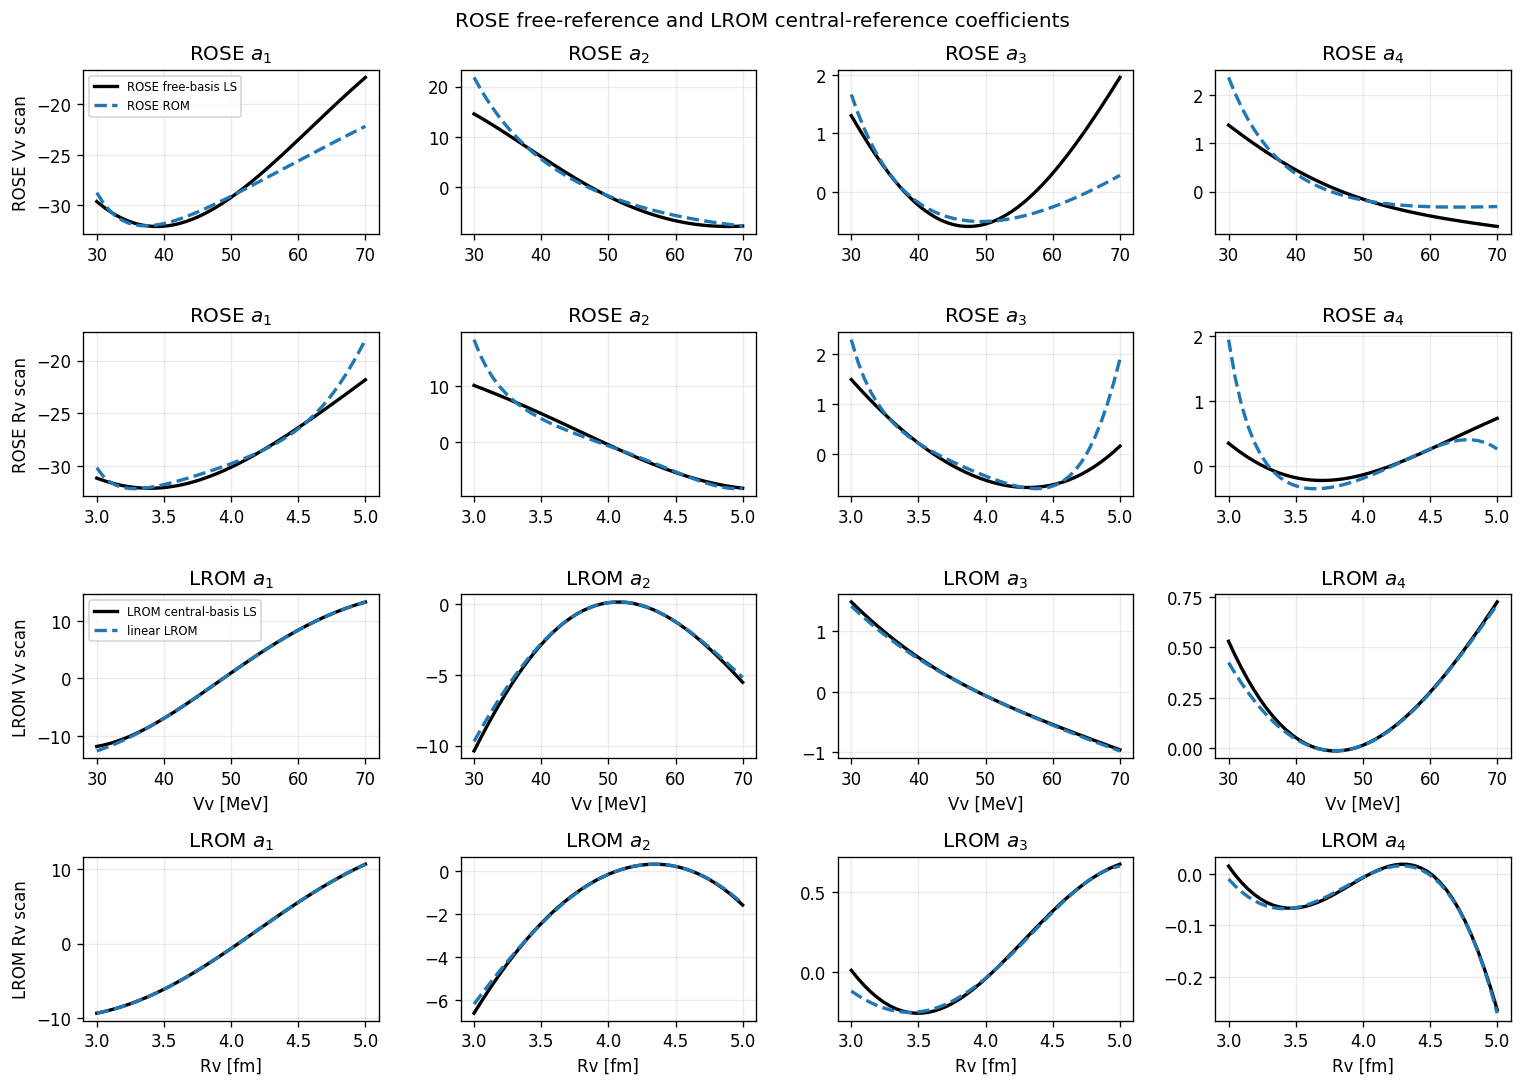

In [14]:
# FIGURE: broad-coefficients
n1_ls = predictor_results.coefficients["ls"][0] if "multiparameter" in "broad-coefficients" else broad_results.coefficients["ls"][0]
n_show = min(BASIS_SIZE, n1_ls.shape[1])
fig, axes = plt.subplots(4, n_show, figsize=(3.2 * n_show, 9.2), squeeze=False)
for scan_index, name in enumerate(("Vv", "Rv")):
    slc, x = scan_slices[name], scan_axes[name]
    for j in range(n_show):
        ax_rose = axes[scan_index, j]
        ax_n1 = axes[scan_index + 2, j]
        ax_rose.plot(x, broad_rose_ls_test[slc, j].real, color='black', lw=2, label='ROSE free-basis LS'); ax_rose.plot(x, broad_rose_coeff_test[slc, j].real, '--', lw=2, label='ROSE ROM')
        ax_n1.plot(x, n1_ls[slc, j].real, color='black', lw=2, label='LROM central-basis LS')
        ax_n1.plot(x, broad_lrom[slc, j].real, "--", lw=2, label="linear LROM")
        ax_rose.set_title(fr"ROSE $a_{j+1}$"); ax_n1.set_title(fr"LROM $a_{j+1}$")
        ax_n1.set_xlabel(f"{name} [{'MeV' if name == 'Vv' else 'fm'}]")
        if j == 0: ax_rose.set_ylabel(f"ROSE {name} scan"); ax_n1.set_ylabel(f"LROM {name} scan")
        if scan_index == 0 and j == 0: ax_rose.legend(fontsize=7); ax_n1.legend(fontsize=7)
fig.suptitle("ROSE free-reference and LROM central-reference coefficients")
fig.tight_layout()
plt.show()

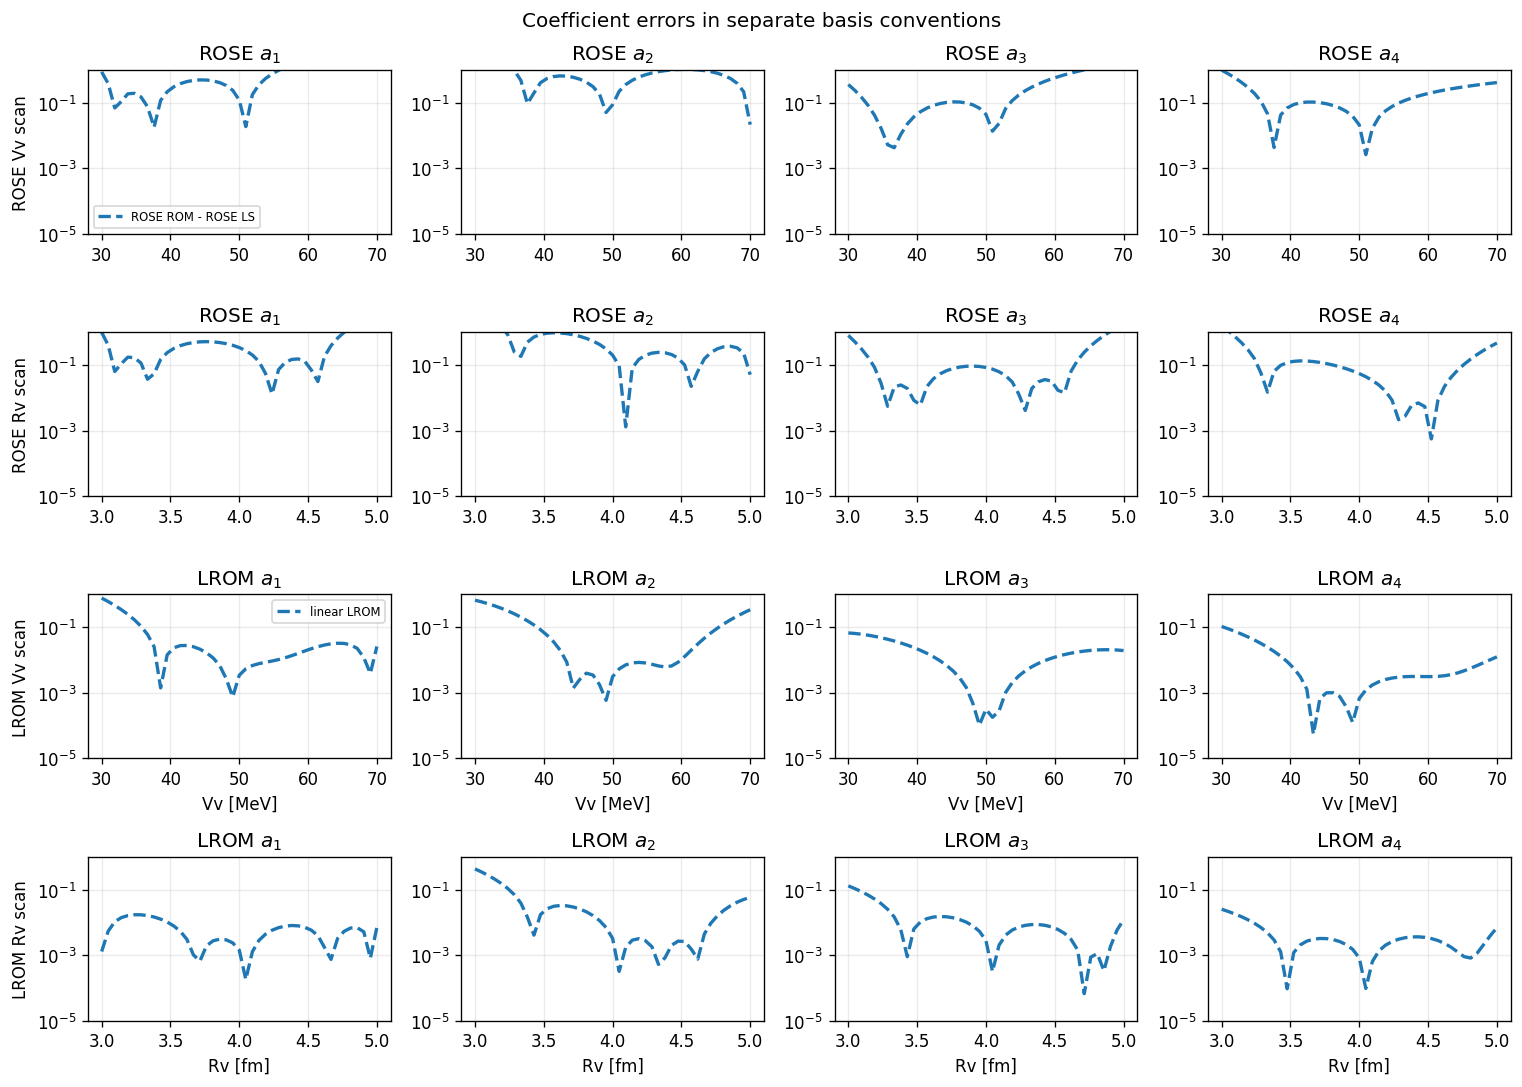

In [15]:
# FIGURE: broad-coefficient-errors
n1_ls = predictor_results.coefficients["ls"][0] if "multiparameter" in "broad-coefficient-errors" else broad_results.coefficients["ls"][0]
n_show = min(BASIS_SIZE, n1_ls.shape[1])
fig, axes = plt.subplots(4, n_show, figsize=(3.2 * n_show, 9.2), squeeze=False)
for scan_index, name in enumerate(("Vv", "Rv")):
    slc, x = scan_slices[name], scan_axes[name]
    for j in range(n_show):
        ax_rose = axes[scan_index, j]
        ax_n1 = axes[scan_index + 2, j]
        ax_rose.semilogy(x, np.maximum(np.abs(broad_rose_coeff_test[slc, j] - broad_rose_ls_test[slc, j]), DIFFERENCE_FLOOR), '--', lw=2, label='ROSE ROM - ROSE LS')
        ax_n1.set_yscale('log')
        ax_n1.semilogy(x, np.maximum(np.abs(broad_lrom[slc, j] - n1_ls[slc, j]), DIFFERENCE_FLOOR), "--", lw=2, label="linear LROM")
        ax_rose.set_title(fr"ROSE $a_{j+1}$"); ax_n1.set_title(fr"LROM $a_{j+1}$")
        ax_n1.set_xlabel(f"{name} [{'MeV' if name == 'Vv' else 'fm'}]")
        if j == 0: ax_rose.set_ylabel(f"ROSE {name} scan"); ax_n1.set_ylabel(f"LROM {name} scan")
        if scan_index == 0 and j == 0: ax_rose.legend(fontsize=7); ax_n1.legend(fontsize=7)
fig.suptitle("Coefficient errors in separate basis conventions")
for difference_ax in axes.ravel():
    difference_ax.set_ylim(bottom=DIFFERENCE_FLOOR, top=ERROR_YMAX)
fig.tight_layout()
plt.show()

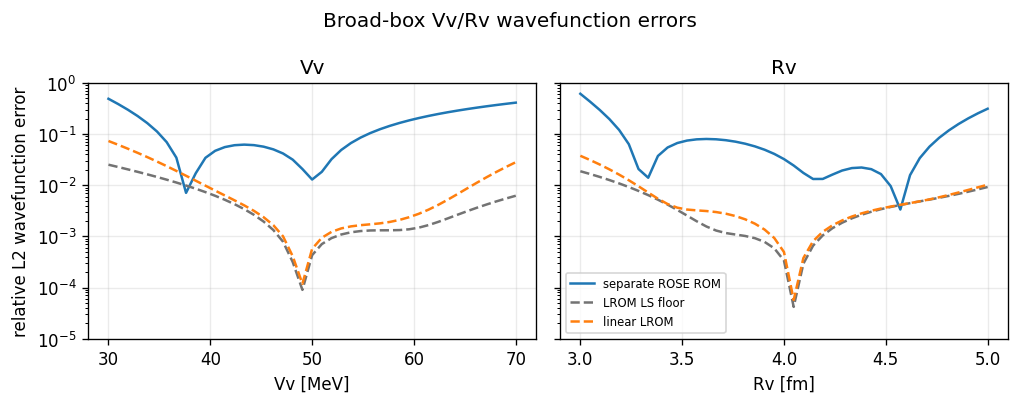

In [16]:
# FIGURE: broad-wavefunction-errors
fig, axes = plt.subplots(1, 2, figsize=(8.6, 3.4), sharey=True)
for ax, name in zip(axes, ("Vv", "Rv")):
    slc, x = scan_slices[name], scan_axes[name]
    ax.semilogy(x, np.maximum(broad_rose_error_test[slc], DIFFERENCE_FLOOR), "-", color="tab:blue", label="separate ROSE ROM")
    ax.semilogy(x, np.maximum(broad_metrics['ls'][slc], DIFFERENCE_FLOOR), "--", color="0.45", label="LROM LS floor")
    ax.semilogy(x, np.maximum(broad_metrics['lrom'][slc], DIFFERENCE_FLOOR), "--", color="tab:orange", label="linear LROM")
    ax.set(xlabel=f"{name} [{'MeV' if name == 'Vv' else 'fm'}]", title=name)
axes[0].set_ylabel("relative L2 wavefunction error")
axes[1].legend(fontsize=7)
fig.suptitle("Broad-box Vv/Rv wavefunction errors")
for difference_ax in axes:
    difference_ax.set_ylim(bottom=DIFFERENCE_FLOOR, top=ERROR_YMAX)
fig.tight_layout()
plt.show()

## Potential predictors

In [17]:
# Study 4: same broad box, but the LROM now uses potential values at
# maxvol-selected radii as predictors instead of the raw parameters.
# The ROSE comparison is unchanged, so aliases suffice.
predictor_emulator = make_broad_emulator("potential", 5)
predictor_state = predictor_emulator.predictors
predictor_results = predictor_emulator.testing_results
radius = predictor_emulator.samples.mesh.radius
predictor_ls = predictor_results.coefficients["ls"][0]
predictor_lrom = predictor_results.coefficients["lrom"][0]
predictor_metrics = predictor_results.metrics["relative_l2"][0]
predictor_rose_emulator = broad_rose_emulator
predictor_rose_rbe = broad_rose_rbe
predictor_rose_coeff_train = broad_rose_coeff_train
predictor_rose_coeff_test = broad_rose_coeff_test
predictor_rose_ls_train = broad_rose_ls_train
predictor_rose_ls_test = broad_rose_ls_test
predictor_rose_wf_train = broad_rose_wf_train
predictor_rose_wf_test = broad_rose_wf_test
predictor_rose_error_train = broad_rose_error_train
predictor_rose_error_test = broad_rose_error_test


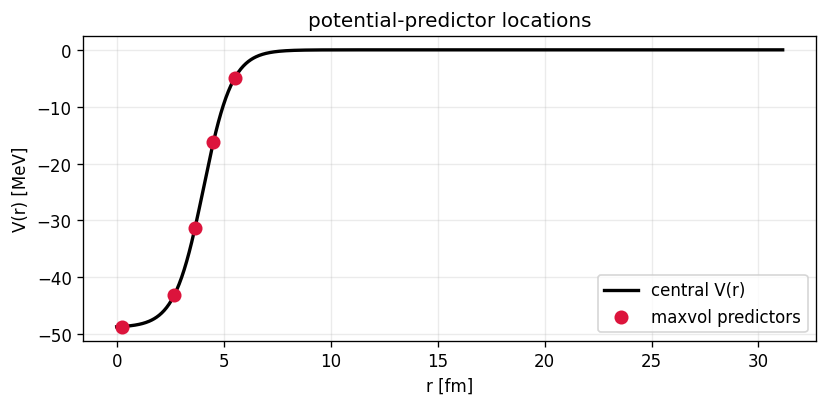

In [18]:
# FIGURE: predictor-points
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(radius, predictor_emulator.samples.central_potential.real, color="black", lw=2, label="central V(r)")
ax.scatter(
    predictor_state.selected_radii,
    predictor_state.central_values.real,
    s=55, color="crimson", zorder=5, label="maxvol predictors",
)
ax.set(xlabel="r [fm]", ylabel="V(r) [MeV]", title="potential-predictor locations")
ax.legend()
fig.tight_layout()
plt.show()

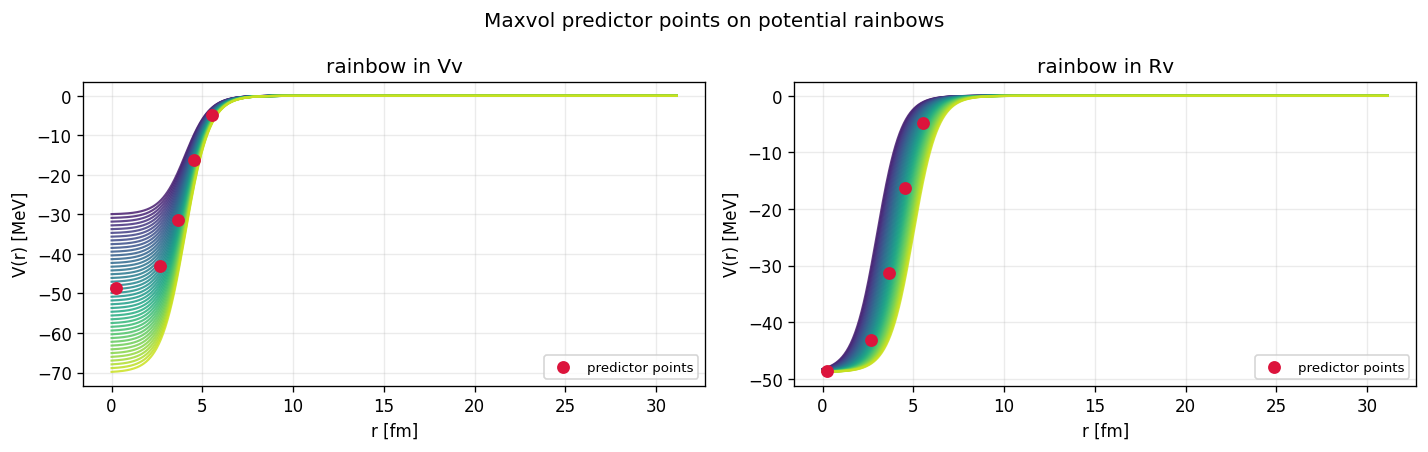

In [19]:
# FIGURE: predictor-rainbows
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
colors = plt.cm.viridis(np.linspace(0.08, 0.92, n_scan))
for ax, name, colorset in zip(axes, ("Vv", "Rv"), (colors, colors)):
    slc = scan_slices[name]
    for color, potential in zip(colorset, predictor_emulator.samples.testing_potentials[slc]):
        ax.plot(radius, potential.real, color=color, lw=1.3, alpha=0.85)
    ax.scatter(
        predictor_state.selected_radii,
        predictor_state.central_values.real,
        color="crimson", s=45, zorder=5, label="predictor points",
    )
    ax.set(xlabel="r [fm]", ylabel="V(r) [MeV]", title=f"rainbow in {name}")
    ax.legend(fontsize=8)
fig.suptitle("Maxvol predictor points on potential rainbows")
fig.tight_layout()
plt.show()

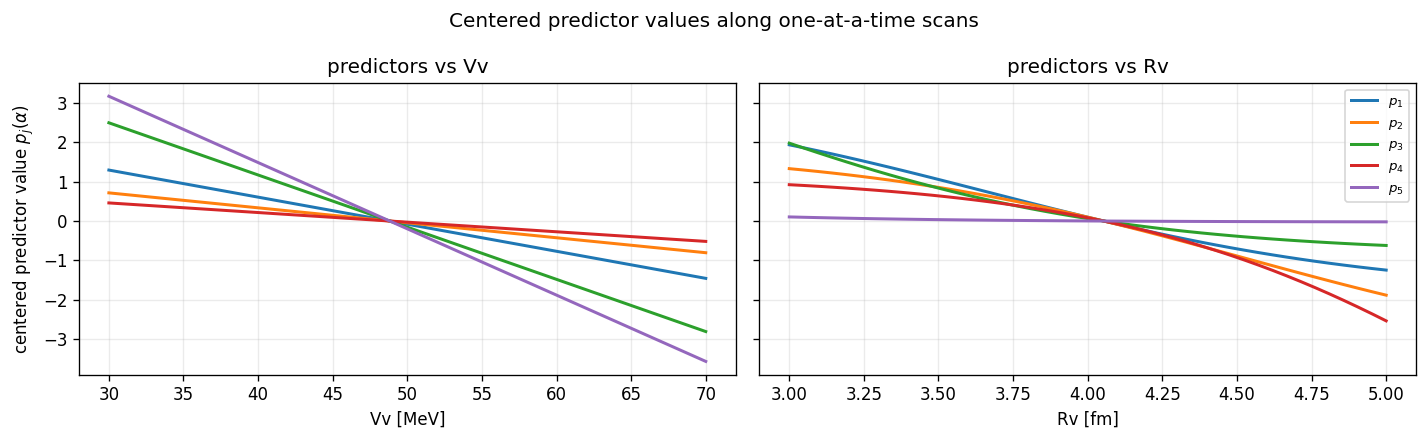

In [20]:
# FIGURE: predictor-values
fig, axes = plt.subplots(1, 2, figsize=(12, 3.7), sharey=True)
for ax, name in zip(axes, ("Vv", "Rv")):
    slc, x = scan_slices[name], scan_axes[name]
    for j in range(predictor_state.testing_features.shape[1]):
        ax.plot(x, predictor_state.testing_features[slc, j], lw=1.8, label=fr"$p_{j+1}$")
    ax.set(xlabel=f"{name} [{'MeV' if name == 'Vv' else 'fm'}]", title=f"predictors vs {name}")
axes[0].set_ylabel(r"centered predictor value $p_j(\alpha)$")
axes[1].legend(fontsize=8)
fig.suptitle("Centered predictor values along one-at-a-time scans")
fig.tight_layout()
plt.show()

## Linear versus predictor LROM

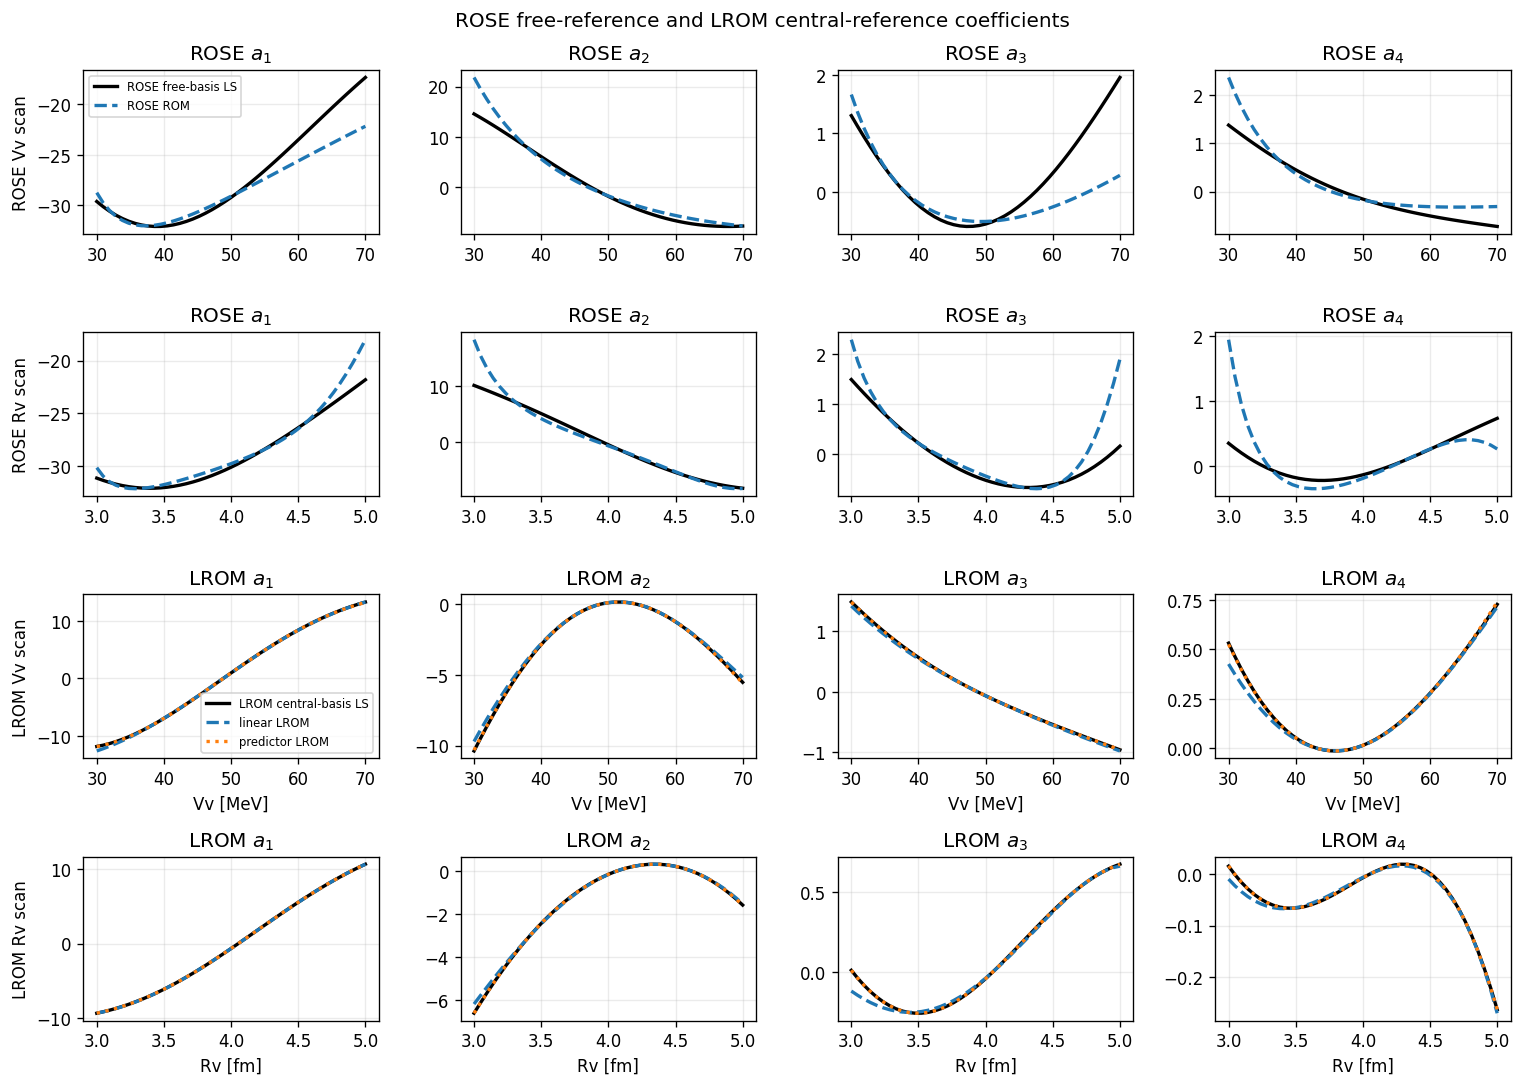

In [21]:
# FIGURE: multiparameter-coefficients
n1_ls = predictor_results.coefficients["ls"][0] if "multiparameter" in "multiparameter-coefficients" else broad_results.coefficients["ls"][0]
n_show = min(BASIS_SIZE, n1_ls.shape[1])
fig, axes = plt.subplots(4, n_show, figsize=(3.2 * n_show, 9.2), squeeze=False)
for scan_index, name in enumerate(("Vv", "Rv")):
    slc, x = scan_slices[name], scan_axes[name]
    for j in range(n_show):
        ax_rose = axes[scan_index, j]
        ax_n1 = axes[scan_index + 2, j]
        ax_rose.plot(x, broad_rose_ls_test[slc, j].real, color='black', lw=2, label='ROSE free-basis LS'); ax_rose.plot(x, broad_rose_coeff_test[slc, j].real, '--', lw=2, label='ROSE ROM')
        ax_n1.plot(x, n1_ls[slc, j].real, color='black', lw=2, label='LROM central-basis LS')
        ax_n1.plot(x, broad_lrom[slc, j].real, "--", lw=2, label="linear LROM")
        ax_n1.plot(x, predictor_lrom[slc, j].real, ":", lw=2, label="predictor LROM")
        ax_rose.set_title(fr"ROSE $a_{j+1}$"); ax_n1.set_title(fr"LROM $a_{j+1}$")
        ax_n1.set_xlabel(f"{name} [{'MeV' if name == 'Vv' else 'fm'}]")
        if j == 0: ax_rose.set_ylabel(f"ROSE {name} scan"); ax_n1.set_ylabel(f"LROM {name} scan")
        if scan_index == 0 and j == 0: ax_rose.legend(fontsize=7); ax_n1.legend(fontsize=7)
fig.suptitle("ROSE free-reference and LROM central-reference coefficients")
fig.tight_layout()
plt.show()

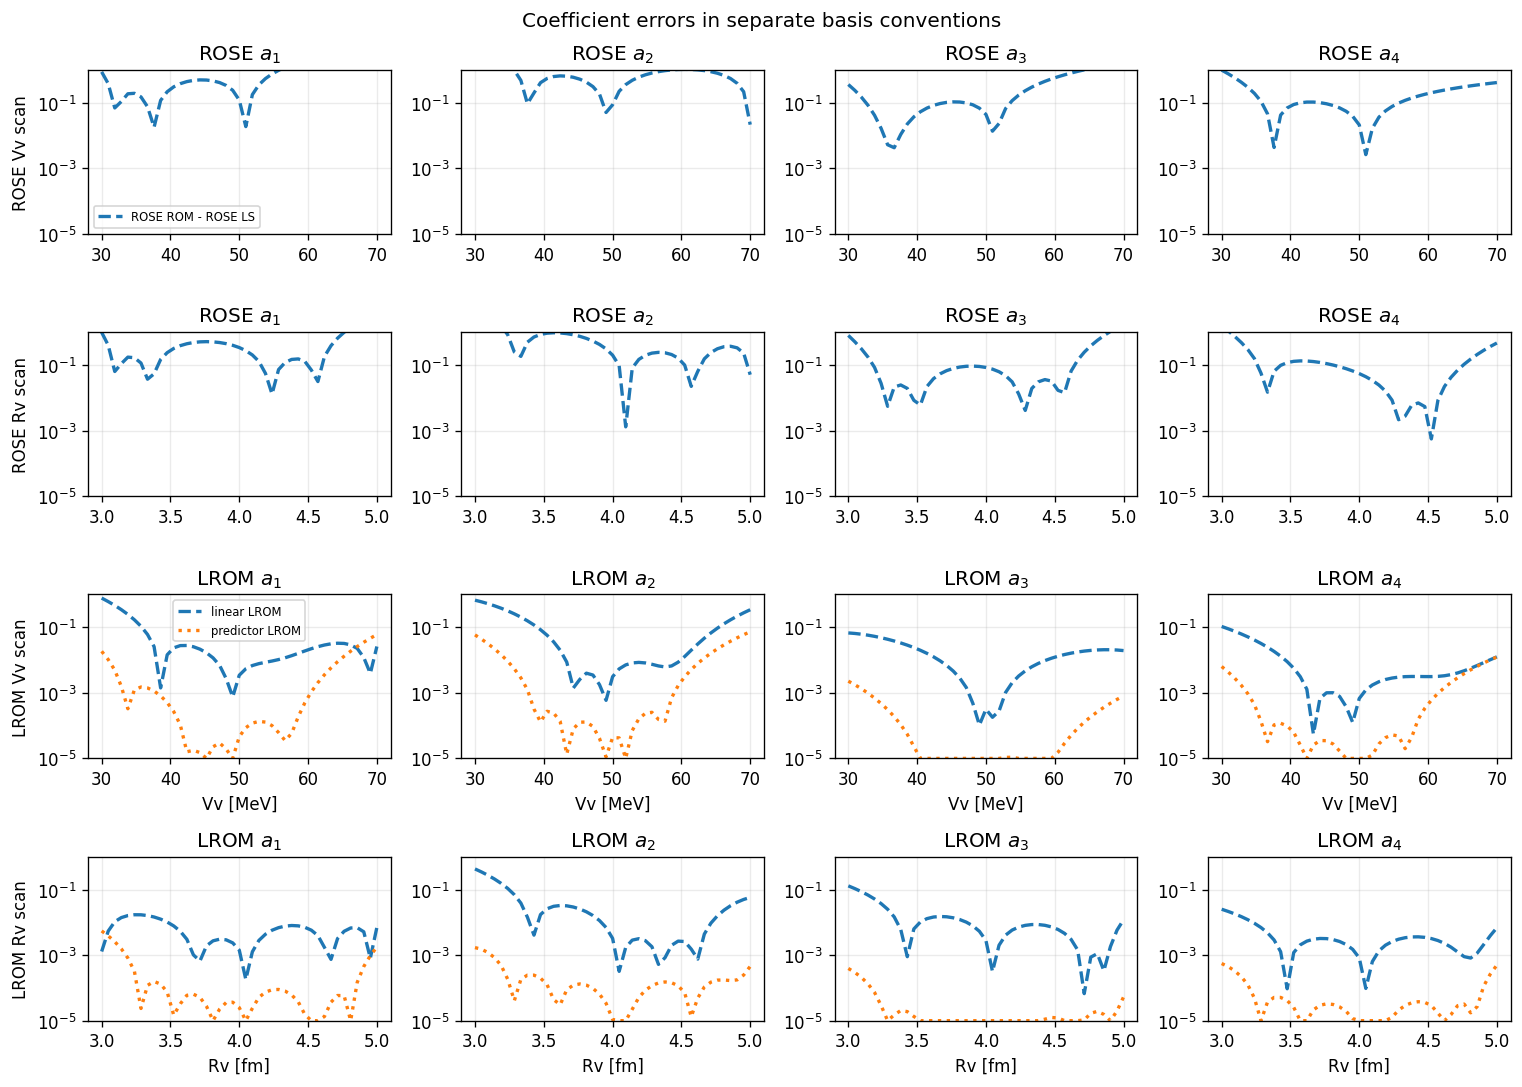

In [22]:
# FIGURE: multiparameter-coefficient-errors
n1_ls = predictor_results.coefficients["ls"][0] if "multiparameter" in "multiparameter-coefficient-errors" else broad_results.coefficients["ls"][0]
n_show = min(BASIS_SIZE, n1_ls.shape[1])
fig, axes = plt.subplots(4, n_show, figsize=(3.2 * n_show, 9.2), squeeze=False)
for scan_index, name in enumerate(("Vv", "Rv")):
    slc, x = scan_slices[name], scan_axes[name]
    for j in range(n_show):
        ax_rose = axes[scan_index, j]
        ax_n1 = axes[scan_index + 2, j]
        ax_rose.semilogy(x, np.maximum(np.abs(broad_rose_coeff_test[slc, j] - broad_rose_ls_test[slc, j]), DIFFERENCE_FLOOR), '--', lw=2, label='ROSE ROM - ROSE LS')
        ax_n1.set_yscale('log')
        ax_n1.semilogy(x, np.maximum(np.abs(broad_lrom[slc, j] - n1_ls[slc, j]), DIFFERENCE_FLOOR), "--", lw=2, label="linear LROM")
        ax_n1.semilogy(x, np.maximum(np.abs(predictor_lrom[slc, j] - n1_ls[slc, j]), DIFFERENCE_FLOOR), ":", lw=2, label="predictor LROM")
        ax_rose.set_title(fr"ROSE $a_{j+1}$"); ax_n1.set_title(fr"LROM $a_{j+1}$")
        ax_n1.set_xlabel(f"{name} [{'MeV' if name == 'Vv' else 'fm'}]")
        if j == 0: ax_rose.set_ylabel(f"ROSE {name} scan"); ax_n1.set_ylabel(f"LROM {name} scan")
        if scan_index == 0 and j == 0: ax_rose.legend(fontsize=7); ax_n1.legend(fontsize=7)
fig.suptitle("Coefficient errors in separate basis conventions")
for difference_ax in axes.ravel():
    difference_ax.set_ylim(bottom=DIFFERENCE_FLOOR, top=ERROR_YMAX)
fig.tight_layout()
plt.show()

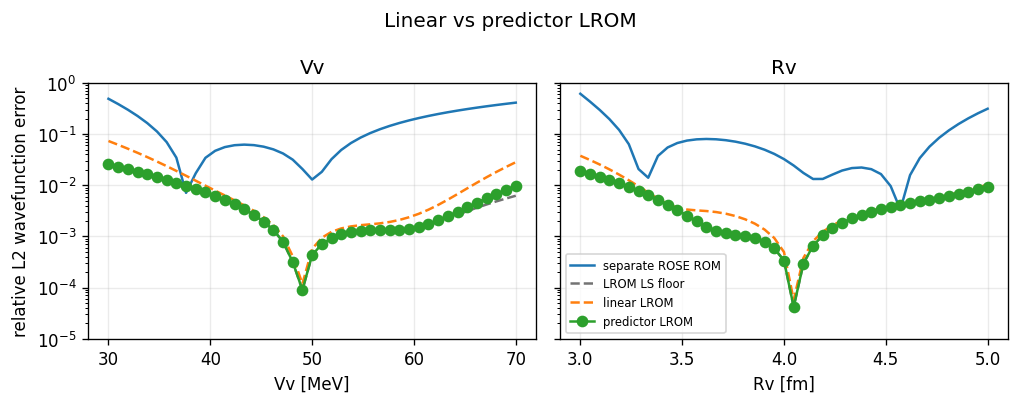

In [23]:
# FIGURE: multiparameter-wavefunction-errors
fig, axes = plt.subplots(1, 2, figsize=(8.6, 3.4), sharey=True)
for ax, name in zip(axes, ("Vv", "Rv")):
    slc, x = scan_slices[name], scan_axes[name]
    ax.semilogy(x, np.maximum(predictor_rose_error_test[slc], DIFFERENCE_FLOOR), "-", color="tab:blue", label="separate ROSE ROM")
    ax.semilogy(x, np.maximum(predictor_metrics['ls'][slc], DIFFERENCE_FLOOR), "--", color="0.45", label="LROM LS floor")
    ax.semilogy(x, np.maximum(broad_metrics['lrom'][slc], DIFFERENCE_FLOOR), "--", color="tab:orange", label="linear LROM")
    ax.semilogy(x, np.maximum(predictor_metrics['lrom'][slc], DIFFERENCE_FLOOR), "o-", color="tab:green", label="predictor LROM")
    ax.set(xlabel=f"{name} [{'MeV' if name == 'Vv' else 'fm'}]", title=name)
axes[0].set_ylabel("relative L2 wavefunction error")
axes[1].legend(fontsize=7)
fig.suptitle("Linear vs predictor LROM")
for difference_ax in axes:
    difference_ax.set_ylim(bottom=DIFFERENCE_FLOOR, top=ERROR_YMAX)
fig.tight_layout()
plt.show()

violin display floor: errors below 1e-05 are clipped visually only
central parameter rows removed from violin distributions
ROSE LS floor    train median=3.746e-03  test median=4.734e-03
LROM LS floor    train median=2.993e-03  test median=3.205e-03
ROSE ROM         train median=4.813e-02  test median=6.593e-02
linear LROM      train median=3.330e-03  test median=4.086e-03
predictor LROM   train median=2.993e-03  test median=3.348e-03


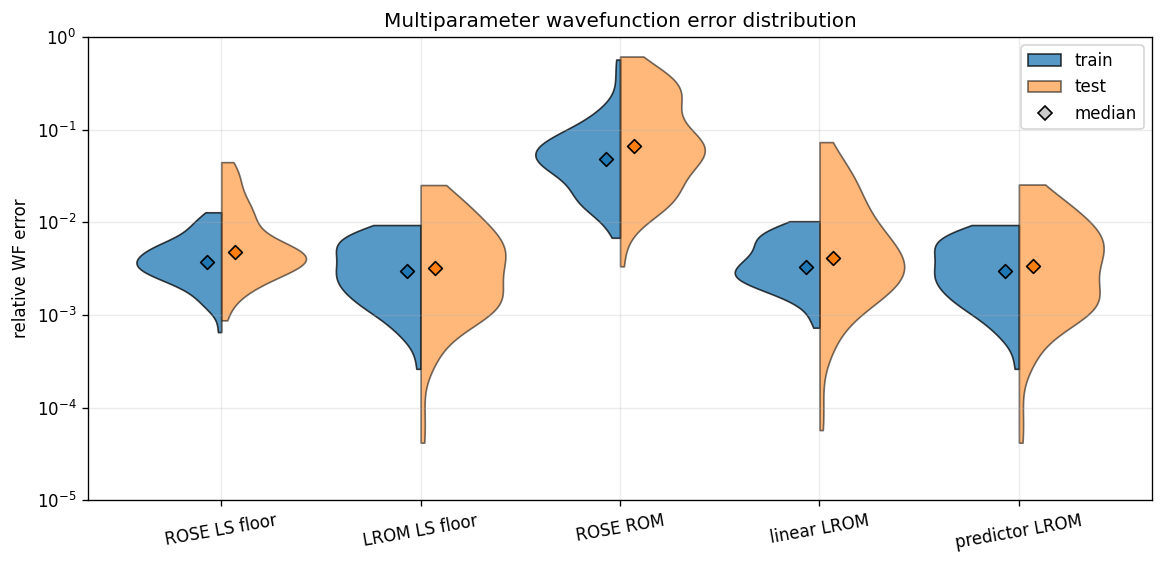

In [24]:
# FIGURE: multiparameter-violins
# Legacy-style split violins: training distribution on the left half of each
# violin, testing on the right, medians marked with diamonds. The two LS
# floors show the best error attainable in each basis convention; the gap
# between a method and its floor is what the coefficient map costs.
train_rows = np.column_stack([broad_train_vv, broad_train_rv])
test_rows = np.column_stack([broad_test_vv, broad_test_rv])
center = np.array([V0, R0])
train_mask = np.any(np.abs(train_rows - center) > 1e-12, axis=1)  # drop exact-central rows
test_mask = np.any(np.abs(test_rows - center) > 1e-12, axis=1)

# ROSE least-squares floor, reconstructed in ROSE's own free-reference basis.
rose_vectors = broad_rose_rbe.basis.vectors
rose_phi0 = broad_rose_rbe.basis.phi_0
fom_train = broad_emulator.samples.training_wavefunctions[0]
fom_test = broad_emulator.samples.testing_wavefunctions[0]
rose_ls_wf_train = rose_phi0[None, :] + broad_rose_ls_train @ rose_vectors.T
rose_ls_wf_test = rose_phi0[None, :] + broad_rose_ls_test @ rose_vectors.T
rose_ls_err_train = np.linalg.norm(rose_ls_wf_train - fom_train, axis=1) / np.linalg.norm(fom_train, axis=1)
rose_ls_err_test = np.linalg.norm(rose_ls_wf_test - fom_test, axis=1) / np.linalg.norm(fom_test, axis=1)

raw_train = broad_emulator.training_results.metrics["relative_l2"][0]
potential_train = predictor_emulator.training_results.metrics["relative_l2"][0]
categories = [
    ("ROSE LS floor", rose_ls_err_train[train_mask], rose_ls_err_test[test_mask]),
    ("LROM LS floor", potential_train["ls"][train_mask], predictor_metrics["ls"][test_mask]),
    ("ROSE ROM", broad_rose_error_train[train_mask], predictor_rose_error_test[test_mask]),
    ("linear LROM", raw_train["lrom"][train_mask], broad_metrics["lrom"][test_mask]),
    ("predictor LROM", potential_train["lrom"][train_mask], predictor_metrics["lrom"][test_mask]),
]
print(f"violin display floor: errors below {DIFFERENCE_FLOOR:g} are clipped visually only")
print("central parameter rows removed from violin distributions")
fig, ax = plt.subplots(figsize=(9.8, 4.8))
positions = np.arange(1, len(categories) + 1)
for center_pos, (label, training, testing) in zip(positions, categories):
    print(f"{label:<16} train median={np.median(training):.3e}  test median={np.median(testing):.3e}")
    for side, values, color, alpha in ((-1, training, "tab:blue", 0.75), (+1, testing, "tab:orange", 0.55)):
        log_values = np.log10(np.clip(values, DIFFERENCE_FLOOR, None))
        parts = ax.violinplot([log_values], positions=[center_pos], widths=0.85, showextrema=False)
        body = parts["bodies"][0]
        vertices = body.get_paths()[0].vertices
        if side < 0:
            vertices[:, 0] = np.minimum(vertices[:, 0], center_pos)
        else:
            vertices[:, 0] = np.maximum(vertices[:, 0], center_pos)
        body.set_facecolor(color)
        body.set_edgecolor("black")
        body.set_alpha(alpha)
        ax.scatter(center_pos + 0.07 * side, np.median(log_values), marker="D", s=34,
                   color=color, edgecolor="black", zorder=6)
ax.set_xticks(positions, [label for label, _, _ in categories], rotation=10)
ticks = np.arange(-5, 1)
ax.set_yticks(ticks, [fr"$10^{{{k}}}$" for k in ticks])
ax.set_ylim(np.log10(DIFFERENCE_FLOOR), 0.0)
ax.set_ylabel("relative WF error")
ax.set_title("Multiparameter wavefunction error distribution")
ax.legend(handles=[
    Patch(facecolor="tab:blue", alpha=0.75, edgecolor="black", label="train"),
    Patch(facecolor="tab:orange", alpha=0.55, edgecolor="black", label="test"),
    Line2D([], [], marker="D", linestyle="None", markerfacecolor="0.8", markeredgecolor="black", label="median"),
])
fig.tight_layout()
plt.show()

## What to notice

The one-parameter depth scan is the cleanest learned reduced-operator problem.
The broader radius and two-parameter scans expose where raw parameter features
lose accuracy. The LROM's selected potential values track the operator shape more
directly, which is visible in the coefficient trajectories and in the final
train/test error distributions.

Why raw-parameter coefficients blow up under wide Rv extrapolation:
the learned implicit operator $A(p) = I + p_{V_v} M_{V_v} + p_{R_v} M_{R_v}$
is only constrained by training data for normalized predictors
$|p| \le 1$. Its determinant, a polynomial in $p$, crosses zero at
$p_{R_v} \approx +3.2$ (about $R_v \approx 6.7$ fm for this design): a
spurious pole. Approaching it, the smallest singular value of $A$ falls
from 1 to $\sim 3\times10^{-3}$ and the solved coordinates explode
($\lVert a \rVert \sim 790$) while the least-squares targets stay bounded
($\lVert a_{LS} \rVert \sim 23$). The global scan windows
(`VV_SCAN_LIMITS`, `RV_SCAN_LIMITS`) keep $|p_{R_v}| \lesssim 1.9$, far
from the pole, so the implicit solves stay well conditioned
(condition number $\lesssim 20$).